In [1]:
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0 = all logs, 1 = INFO, 2 = WARNING, 3 = ERROR only
import warnings
warnings.filterwarnings("ignore")


In [2]:
import numpy as np
import tensorflow as tf

In [3]:
import sys

# Suppress TensorFlow log messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Force early GPU initialization
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        with tf.device('/GPU:0'):
            _ = tf.constant([1.0])
    except RuntimeError as e:
        print(f"RuntimeError during GPU warm-up: {e}")

print("\n" + "="*60)
print("TENSORFLOW GPU TEST RESULTS")
print("="*60)

# TensorFlow version
print(f"TensorFlow Version: {tf.__version__}")

# Python version
print(f"Python Version: {sys.version.split()[0]}")

# CUDA and cuDNN support (inferred)
build_info = tf.sysconfig.get_build_info()
cuda_version = build_info.get('cuda_version', 'Unknown')
cudnn_version = build_info.get('cudnn_version', 'Unknown')

print(f"CUDA Version (from build): {cuda_version}")
print(f"cuDNN Version (from build): {cudnn_version}")

# GPU status
gpu_available = len(gpus) > 0
print(f"\nGPU Available: {gpu_available}")

if gpu_available:
    for idx, gpu in enumerate(gpus):
        print(f"GPU {idx}: {gpu.name}")
else:
    print("No GPU devices detected. Defaulting to CPU.")

# Matrix multiplication test
print(f"\nRunning matrix multiplication test...")
with tf.device('/GPU:0' if gpu_available else '/CPU:0'):
    a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
    b = tf.constant([[1.0, 0.0], [0.0, 1.0]])
    c = tf.matmul(a, b)

print(f"Result:")
print(c.numpy())
print("\nTest completed successfully.")
print("="*60)


TENSORFLOW GPU TEST RESULTS
TensorFlow Version: 2.15.0
Python Version: 3.10.12
CUDA Version (from build): 12.2
cuDNN Version (from build): 8

GPU Available: True
GPU 0: /physical_device:GPU:0

Running matrix multiplication test...
Result:
[[1. 2.]
 [3. 4.]]

Test completed successfully.


In [4]:
# Input vector and layer parameters
x = np.random.normal(size=[1, 4]).astype('float32')

init = tf.keras.initializers.RandomNormal()
w1 = tf.Variable(init(shape=[4, 3]))
b1 = tf.Variable(init(shape=[1, 3]))
w2 = tf.Variable(init(shape=[3, 2]))
b2 = tf.Variable(init(shape=[1, 2]))


In [5]:
@tf.function
def forward(x, W, b, act):
    return act(tf.matmul(x,W)+b)

In [6]:
# Computing h
h = forward(x, w1, b1, tf.nn.sigmoid)

# Computing y
y = forward(h, w2, b2, tf.nn.softmax)

print(y)


tf.Tensor([[0.5104662 0.4895338]], shape=(1, 2), dtype=float32)


In [7]:
v1 = tf.Variable(tf.constant(2.0, shape=[4]), dtype='float32')
print(v1)


<tf.Variable 'Variable:0' shape=(4,) dtype=float32, numpy=array([2., 2., 2., 2.], dtype=float32)>


In [8]:
v2 = tf.Variable(np.ones(shape=[4,3]), dtype='float32')
print(v2)


<tf.Variable 'Variable:0' shape=(4, 3) dtype=float32, numpy=
array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]], dtype=float32)>


In [9]:
v3 = tf.Variable(tf.keras.initializers.RandomNormal()(shape=[3,4,5]), dtype='float32')
print(v3)


<tf.Variable 'Variable:0' shape=(3, 4, 5) dtype=float32, numpy=
array([[[-0.07482667,  0.02475612, -0.02832352, -0.01068908,
          0.03590485],
        [ 0.02636251, -0.03158774, -0.01001069,  0.04110239,
         -0.00363848],
        [ 0.00581103, -0.00707862, -0.05148062,  0.04419037,
         -0.07002492],
        [ 0.03605201, -0.04110717,  0.08744721, -0.0805473 ,
         -0.00097142]],

       [[-0.02282467, -0.06220527, -0.05097862,  0.02669721,
         -0.07750196],
        [ 0.02166669,  0.0326442 ,  0.0529078 ,  0.01901041,
          0.00560512],
        [-0.10203727, -0.06845637,  0.06726328,  0.05140325,
         -0.00149858],
        [-0.07933763,  0.08694768, -0.01599528, -0.11894219,
         -0.04576605]],

       [[-0.02699817, -0.03670969, -0.09577254, -0.01433782,
          0.0553922 ],
        [-0.10269874, -0.0031001 , -0.00875995, -0.04408341,
          0.05084809],
        [ 0.00012487, -0.05586829,  0.07933673, -0.00693457,
          0.00461428],
        

In [10]:
arr = v1.numpy()
print(arr)

[2. 2. 2. 2.]


In [11]:
v = tf.Variable(np.zeros(shape=[4,3]), dtype='float32')
v = v[0,2].assign(1)
print(v)


<tf.Variable 'UnreadVariable' shape=(4, 3) dtype=float32, numpy=
array([[0., 0., 1.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]], dtype=float32)>


In [12]:
v = v[2:, :2].assign([[3,3],[3,3]])
print(v)

<tf.Variable 'UnreadVariable' shape=(4, 3) dtype=float32, numpy=
array([[0., 0., 1.],
       [0., 0., 0.],
       [3., 3., 0.],
       [3., 3., 0.]], dtype=float32)>


In [13]:
v_test = tf.Variable(np.array([[1, 2, 3], [4, 3, 2]], dtype=np.int16))
print(v_test)

<tf.Variable 'Variable:0' shape=(2, 3) dtype=int16, numpy=
array([[1, 2, 3],
       [4, 3, 2]], dtype=int16)>


In [15]:
v = tf.Variable(np.ones(shape=[4,3]), dtype='float32')
b = v * 3.0
print(b)
print(type(b).__name__)

tf.Tensor(
[[3. 3. 3.]
 [3. 3. 3.]
 [3. 3. 3.]
 [3. 3. 3.]], shape=(4, 3), dtype=float32)
EagerTensor


In [18]:
assert isinstance(b, tf.Tensor)
print(type(b).__name__)

EagerTensor


In [19]:
a = tf.constant(2, shape=[4], dtype='float32')
b = tf.constant(3, shape=[4], dtype='float32')
c = tf.add(a,b)
print(c)

tf.Tensor([5. 5. 5. 5.], shape=(4,), dtype=float32)


In [21]:
assert isinstance(c, tf.Tensor)
print(type(c).__name__, c)

EagerTensor tf.Tensor([5. 5. 5. 5.], shape=(4,), dtype=float32)


In [22]:
#Just for fun we'll try to change a tf.Tensor and watch the interpreter object, because it's immutable
a = tf.constant(2, shape=[4], dtype='float32')
a = a[0].assign(2.0)
#Clearly, TF isn't amused by our rebellious act lol

AttributeError: 'tensorflow.python.framework.ops.EagerTensor' object has no attribute 'assign'

In [23]:
a = tf.constant(4, shape=[4], dtype='float32')
b = tf.constant(2, shape=[4], dtype='float32')

In [24]:
print(a)
print(b)

tf.Tensor([4. 4. 4. 4.], shape=(4,), dtype=float32)
tf.Tensor([2. 2. 2. 2.], shape=(4,), dtype=float32)


In [25]:
c = a+b
print(c)

tf.Tensor([6. 6. 6. 6.], shape=(4,), dtype=float32)


In [26]:
e = a*b
print(e)

tf.Tensor([8. 8. 8. 8.], shape=(4,), dtype=float32)


In [27]:
a = tf.constant([[1,2,3],[4,5,6]])
b = tf.constant([[5,4,3],[3,2,1]])
equal_check = (a==b)
print(equal_check)

tf.Tensor(
[[False False  True]
 [False False False]], shape=(2, 3), dtype=bool)


In [28]:
leq_check = (a<=b)
print(leq_check)

tf.Tensor(
[[ True  True  True]
 [False False False]], shape=(2, 3), dtype=bool)


In [29]:
a = tf.constant(np.random.normal(size=[5,4,3]), dtype='float32')
print(a)

tf.Tensor(
[[[-0.5750928  -0.7416862  -0.061333  ]
  [ 0.40782565  0.56113166  0.5512046 ]
  [-0.26159397 -1.059524   -0.58507484]
  [-0.17547458  0.48350862 -1.0836996 ]]

 [[-0.7898844   0.502237   -1.1147516 ]
  [ 0.9313483   0.3644732  -2.594664  ]
  [-0.24705565  1.1786264   1.8671135 ]
  [ 0.20273681  1.9664744  -2.9460976 ]]

 [[ 0.83601886  1.2620121  -0.3396903 ]
  [-0.38930756  2.2520769  -0.48400933]
  [-1.8218833  -1.0574054  -1.8005786 ]
  [-0.6870714   0.14138529  0.75325376]]

 [[ 0.621169    0.8460742   0.82089806]
  [-0.842312    0.22927137  0.3436078 ]
  [ 0.9471714   1.3282893  -0.7139959 ]
  [-1.1793121   0.03876898  0.58207893]]

 [[ 0.44930324 -0.4713966  -0.8409925 ]
  [-2.813004    0.32865888 -0.3388131 ]
  [-1.2076267  -0.258959   -1.2074167 ]
  [-0.7989134  -1.032062    1.126097  ]]], shape=(5, 4, 3), dtype=float32)


In [30]:
for i in range(a.shape[0]):
    print(f"Matrix {i}:\n", a[i].numpy(), "\n")


Matrix 0:
 [[-0.5750928  -0.7416862  -0.061333  ]
 [ 0.40782565  0.56113166  0.5512046 ]
 [-0.26159397 -1.059524   -0.58507484]
 [-0.17547458  0.48350862 -1.0836996 ]] 

Matrix 1:
 [[-0.7898844   0.502237   -1.1147516 ]
 [ 0.9313483   0.3644732  -2.594664  ]
 [-0.24705565  1.1786264   1.8671135 ]
 [ 0.20273681  1.9664744  -2.9460976 ]] 

Matrix 2:
 [[ 0.83601886  1.2620121  -0.3396903 ]
 [-0.38930756  2.2520769  -0.48400933]
 [-1.8218833  -1.0574054  -1.8005786 ]
 [-0.6870714   0.14138529  0.75325376]] 

Matrix 3:
 [[ 0.621169    0.8460742   0.82089806]
 [-0.842312    0.22927137  0.3436078 ]
 [ 0.9471714   1.3282893  -0.7139959 ]
 [-1.1793121   0.03876898  0.58207893]] 

Matrix 4:
 [[ 0.44930324 -0.4713966  -0.8409925 ]
 [-2.813004    0.32865888 -0.3388131 ]
 [-1.2076267  -0.258959   -1.2074167 ]
 [-0.7989134  -1.032062    1.126097  ]] 



In [31]:
red_a1 = tf.reduce_sum(a)
print(red_a1)

tf.Tensor(-8.597866, shape=(), dtype=float32)


In [32]:
red_a2 = tf.reduce_prod(a, axis=0)
print(red_a2)

tf.Tensor(
[[ 0.10599048  0.18749398  0.01603381]
 [-0.3503667   0.03470634 -0.0805881 ]
 [ 0.13468039 -0.45420524  1.6956925 ]
 [ 0.02302911 -0.00537882  1.5763586 ]], shape=(4, 3), dtype=float32)


In [33]:
red_a3 = tf.reduce_min(a, axis=[0,1])
print(red_a3)

tf.Tensor([-2.813004  -1.059524  -2.9460976], shape=(3,), dtype=float32)


In [34]:
# Reducing with keepdims=False
red_a1 = tf.reduce_min(a, axis=1)
print(red_a1.shape)

(5, 3)


In [35]:
# Reducing with keepdims=True
red_a2 = tf.reduce_min(a, axis=1, keepdims=True)
print(red_a2.shape)

(5, 1, 3)


In [49]:
d = tf.constant([[1, 2, 3],
                 [3, 4, 5],
                 [6, 5, 4]])

d_max1 = tf.argmax(d, axis=0)
print(d)
print(d_max1)

tf.Tensor(
[[1 2 3]
 [3 4 5]
 [6 5 4]], shape=(3, 3), dtype=int32)
tf.Tensor([2 2 1], shape=(3,), dtype=int64)


In [48]:
d = tf.constant([[1, 2, 3],
                 [3, 4, 5],
                 [6, 5, 4]])

d_min1 = tf.argmin(d, axis=1)
print(d)
print(d_min1)

tf.Tensor(
[[1 2 3]
 [3 4 5]
 [6 5 4]], shape=(3, 3), dtype=int32)
tf.Tensor([0 0 2], shape=(3,), dtype=int64)


In [45]:
e = tf.constant([1, 2, 3, 4, 5])
e_cumsum = tf.cumsum(e)
print(e_cumsum)


tf.Tensor([ 1  3  6 10 15], shape=(5,), dtype=int32)


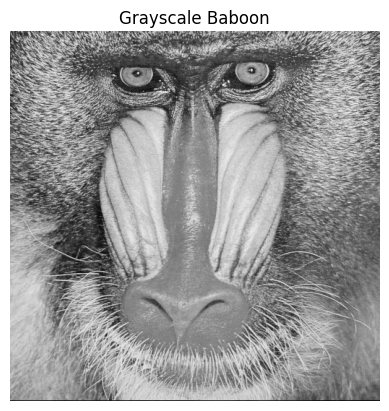

In [52]:
from PIL import Image
import matplotlib.pyplot as plt

# Load image and convert to float32 numpy array
img = Image.open("/home/jwens/PycharmProjects/School-Projects/Graduate Projects - MS AI and Machine Learning/CSC580 Capstone/Week2 Reading/baboon.png")
x_rgb = np.array(img).astype('float32')

# Convert to tensor
x_rgb = tf.constant(x_rgb)

# Define grayscale conversion weights
grays = tf.constant([[0.3], [0.59], [0.11]])

# Reshape for matmul: [height, width, channels] -> [height*width, 3]
h, w, c = x_rgb.shape
x_reshaped = tf.reshape(x_rgb, [-1, 3])

# Matrix multiply to apply grayscale weights
x_gray = tf.matmul(x_reshaped, grays)

# Reshape back to original image height and width
x_gray = tf.reshape(x_gray, [h, w])

# Visualize
plt.imshow(x_gray.numpy(), cmap='gray')
plt.axis('off')
plt.title("Grayscale Baboon")
plt.show()


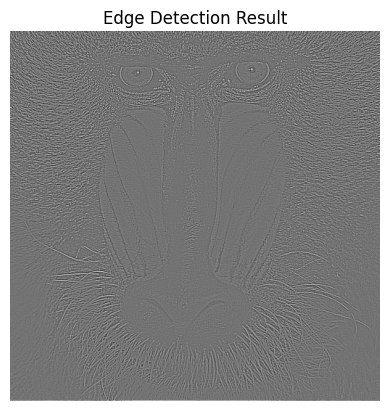

In [53]:
# Define the Laplacian edge detection filter
filter = tf.Variable(np.array([[-1, -1, -1],
                               [-1,  8, -1],
                               [-1, -1, -1]]).astype('float32'))

# Reshape grayscale image to match tf.nn.convolution input: [1, height, width, 1]
y_reshaped = tf.reshape(x_gray, [1, x_gray.shape[0], x_gray.shape[1], 1])

# Reshape filter to match tf.nn.convolution kernel format: [filter_height, filter_width, in_channels, out_channels]
filter_reshaped = tf.reshape(filter, [3, 3, 1, 1])

# Apply 2D convolution
y_conv = tf.nn.convolution(y_reshaped, filter_reshaped)

# Squeeze back to [height, width] for visualization
y_edges = tf.squeeze(y_conv)

# Display result
plt.imshow(y_edges.numpy(), cmap='gray')
plt.axis('off')
plt.title("Edge Detection Result")
plt.show()


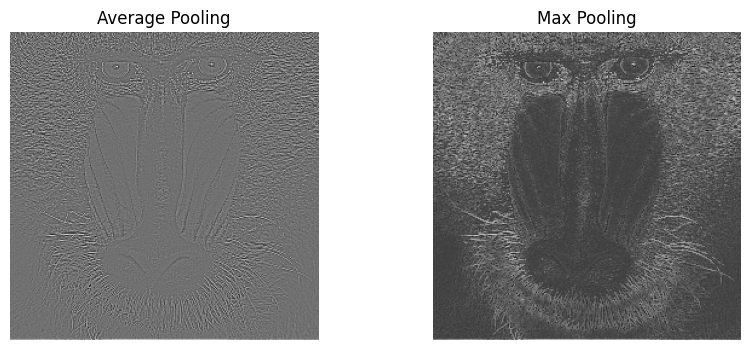

In [54]:
# Perform average pooling
z_avg = tf.nn.avg_pool(y_conv, ksize=(1, 2, 2, 1), strides=(1, 2, 2, 1), padding='VALID')

# Perform max pooling
z_max = tf.nn.max_pool(y_conv, ksize=(1, 2, 2, 1), strides=(1, 2, 2, 1), padding='VALID')

# Remove unnecessary dimensions for visualization
z_avg = np.squeeze(z_avg.numpy())
z_max = np.squeeze(z_max.numpy())

# Display results
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(z_avg, cmap='gray')
plt.title("Average Pooling")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(z_max, cmap='gray')
plt.title("Max Pooling")
plt.axis('off')

plt.show()
